# DeSCENT Pipeline Demo

**De**convolution-guided **S**ingle-**C**ell **E**xpression for Survival Predictio**N** using **T**ranscriptomics

This notebook walks through the DeSCENT pipeline on **BRCA** (breast cancer). DEG lists are assumed to be pre-computed (via `run_deg_cv.py` or provided externally).

### Data Flow
```
bulk RNA-seq + scRNA-seq reference
        │
        ▼
   Step 1: ReDeconv ──► cell fractions
        │
        ▼
   Step 2: scDiffusion training / fine-tuning ──► VAE / diffusion / classifier checkpoints
        │
        ▼
   Step 3: scDiffusion condgen ──► synthetic scGEP (.npz)
        │
        ▼
   Step 4: Multimodal survival CV (bulk + scGEP + DEG) ──► C-index
```

### Prerequisites
- `conda activate descent` (see `environment.yml`)
- Data files under `data/BRCA/` and pre-computed DEG files (global or per-fold)
- Download the upstream scimilarity pretrained directory `annotation_model_v1` and place it at `data/pretrained/annotation_model_v1/`

## Environment & Configuration

In [2]:
from pathlib import Path
import os
import json

def find_root():
    p = Path.cwd().resolve()
    if (p / "DeSCENT" / "config" / "path_local.json").exists():
        return p / "DeSCENT"
    for parent in [p, *p.parents]:
        if (parent / "config" / "path_local.json").exists():
            return parent
    raise RuntimeError("Run this notebook inside the DeSCENT repo")

DESCENT_ROOT = find_root()
os.chdir(DESCENT_ROOT)
os.environ["DESCENT_ROOT"] = str(DESCENT_ROOT)

# Fix CXXABI_1.3.15 errors on older systems
conda_prefix = os.environ.get("CONDA_PREFIX", "")
if conda_prefix and Path(conda_prefix, "lib").is_dir():
    ld = os.environ.get("LD_LIBRARY_PATH", "")
    os.environ["LD_LIBRARY_PATH"] = f"{conda_prefix}/lib:{ld}" if ld else f"{conda_prefix}/lib"

# --- Cancer type (change to run other cancers) ---
CANCER = "BRCA"

# --- Training / generation controls ---
SCDIFFUSION_TRAIN_MODE = "auto"      # auto | force | skip
QUIET = True                         # notebook-wide quiet mode for training and condgen commands
VAE_MAX_STEPS = 200000
DIFFUSION_LR_ANNEAL_STEPS = 500000
CLASSIFIER_ITERATIONS = 500000
CONDGEN_SAMPLE_LIMIT = 0              # Set to None or 0 to use the full fraction file in Step 3
CONDGEN_PREVIEW_SAMPLES = 0              # Number of generated samples to summarize; 0 disables preview, None shows all

# --- Load config ---
with open(DESCENT_ROOT / "config" / "path_local.json") as f:
    CONFIG = json.load(f)
cfg = CONFIG[CANCER]

print(f"DESCENT_ROOT : {DESCENT_ROOT}")
print(f"CANCER       : {CANCER}")
print(f"Train mode   : {SCDIFFUSION_TRAIN_MODE}")
print(f"Notebook quiet: {QUIET}")
print(f"Config keys  : {list(cfg.keys())}")

DESCENT_ROOT : /data/zhaoyh/DeSCENT
CANCER       : BRCA
Train mode   : auto
Notebook quiet: True
Config keys  : ['cancer', 'single_cell_data', 'VAE_pretrained', 'VAE', 'diffusion_backbone', 'classifier', 'sc_npz', 'bulk', 'surv_label', 'deg', 'gene_list', 'celltypes', 'redeconv_ref', 'bulk_tpm', 'bulk_recount3_dir', 'gene_list_path']


In [3]:
import subprocess, gc, torch
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def gpu_cleanup():
    """Clear GPU memory between pipeline steps (mirrors shell scripts)."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

In [4]:
def resolve(p):
    """Resolve a config path relative to DESCENT_ROOT."""
    if not p:
        return None
    p = Path(p)
    return p if p.is_absolute() else (DESCENT_ROOT / p)

input_checks = {
    "sc_train":      resolve(cfg["single_cell_data"]["train"]),
    "sc_test":       resolve(cfg["single_cell_data"]["test"]),
    "bulk_tpm":      resolve(cfg["bulk_tpm"]),
    "surv_label":    resolve(cfg["surv_label"]),
    "gene_list":     resolve(cfg["gene_list"]),
    "VAE_pretrained": resolve(cfg.get("VAE_pretrained", "")),
    "redeconv_ref":  resolve(cfg["redeconv_ref"]),
    "deg (global)":  resolve(cfg.get("deg", "")),
}
expected_outputs = {
    "VAE":        resolve(cfg["VAE"]),
    "diffusion":  resolve(cfg["diffusion_backbone"]),
    "classifier": resolve(cfg["classifier"]),
    "sc_npz":     resolve(cfg["sc_npz"]),
}
model_outputs = {k: v for k, v in expected_outputs.items() if k in {"VAE", "diffusion", "classifier"}}
needs_training = SCDIFFUSION_TRAIN_MODE == "force" or any(not path.exists() for path in model_outputs.values())

all_ok = True
for name, path in input_checks.items():
    if name == "VAE_pretrained" and (SCDIFFUSION_TRAIN_MODE == "skip" or not needs_training):
        status = "↷ not needed unless training runs" if not path or not path.exists() else "✓"
    elif path is None:
        status = "⚠ not configured"
        all_ok = False
    elif path.exists():
        status = "✓"
    else:
        status = f"✗ missing: {path}"
        all_ok = False
    print(f"  {name:16s} {status}")

for name, path in expected_outputs.items():
    if path is not None and path.exists() and SCDIFFUSION_TRAIN_MODE != "force":
        status = "✓ exists"
    elif name in model_outputs:
        if SCDIFFUSION_TRAIN_MODE == "skip":
            status = f"✗ missing: {path}"
            all_ok = False
        elif SCDIFFUSION_TRAIN_MODE == "force":
            status = f"↻ will retrain -> {path}"
        else:
            status = f"⏳ will train -> {path}"
    else:
        status = f"⏳ will generate -> {path}"
    print(f"  {name:16s} {status}")

tcga_umi = Path("/data/youzy/tcga_umi") / f"{CANCER.lower()}.csv"
print(f"  {'tcga_umi':16s} {'✓' if tcga_umi.exists() else '✗ missing: ' + str(tcga_umi)}")

print()
print("Environment looks ready." if all_ok else "Some required inputs are missing — affected steps will fail.")


  sc_train         ✓
  sc_test          ✓
  bulk_tpm         ✓
  surv_label       ✓
  gene_list        ✓
  VAE_pretrained   ✓
  redeconv_ref     ✓
  deg (global)     ✓
  VAE              ✓ exists
  diffusion        ✓ exists
  classifier       ✓ exists
  sc_npz           ✓ exists
  tcga_umi         ✓

Environment looks ready.


## Step 1 — ReDeconv (Cell Fraction Estimation)

Estimate cell-type fractions from bulk RNA-seq using the bundled **ReDeconv** (patched fork).

- **Input**: scRNA-seq reference (`Meta_data_new.tsv`, `scRNA_seq_new_noShift.tsv`), bulk TPM
- **Output**: `output/redeconv_fraction/{CANCER}/{CANCER}_ratios_redeconv_10.csv`
- **Note**: Do NOT `pip install redeconv` — it overwrites the local patches.

In [ ]:
REDECONV_OUT = str(DESCENT_ROOT / "output" / "redeconv_fraction" / CANCER)
os.makedirs(REDECONV_OUT, exist_ok=True)

print(f"ReDeconv output: {REDECONV_OUT}")

redeconv_cmd = [
    "python",
    "pipeline_scripts/run_redeconv_full.py",
    "--cancer", CANCER,
    "--config", f"{DESCENT_ROOT}/config/path_local.json",
    "--out_dir", REDECONV_OUT,
]
print("Running:", " ".join(redeconv_cmd))
subprocess.run(redeconv_cmd, cwd=str(DESCENT_ROOT / "scgep_generation"), check=True)

gpu_cleanup()
print()
print(f"→ Expected output: {REDECONV_OUT}/{CANCER}_ratios_redeconv_10.csv")


### ReDeconv Results Inspection

Shape: 1111 samples × 9 cell types
Cell types: ['B-cells', 'CAFs', 'Cancer Epithelial', 'Endothelial', 'Myeloid', 'Normal Epithelial', 'PVL', 'Plasmablasts', 'T-cells']



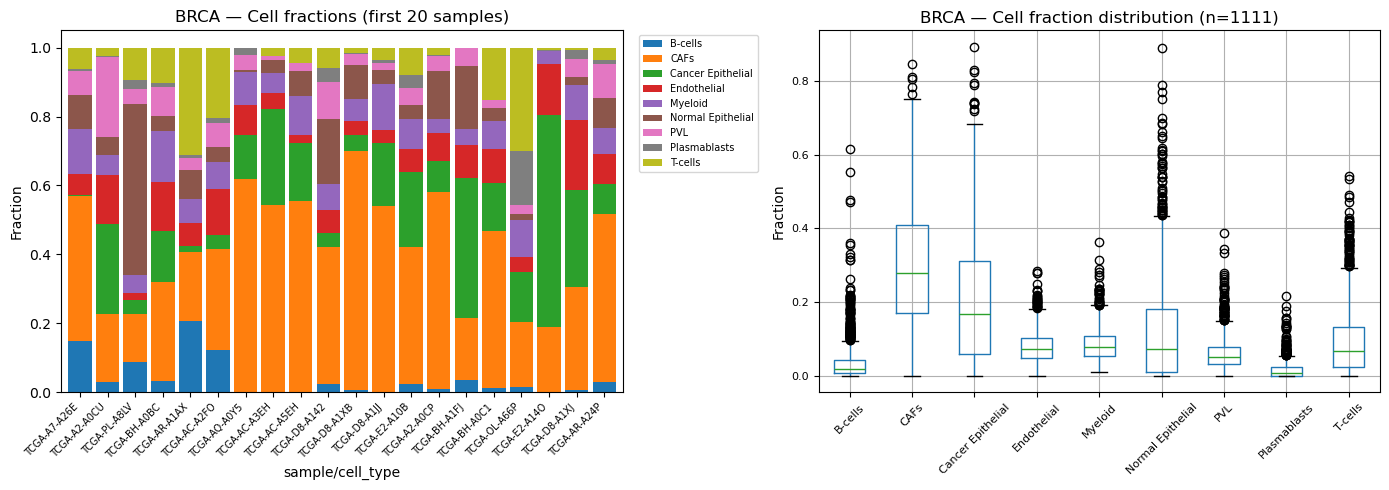

In [10]:
frac_path = DESCENT_ROOT / "output" / "redeconv_fraction" / CANCER / f"{CANCER}_ratios_redeconv_10.csv"

if not frac_path.exists():
    print(f"Fraction file not found: {frac_path} — run Step 1 first.")
else:
    frac_df = pd.read_csv(frac_path, index_col=0)
    print(f"Shape: {frac_df.shape[0]} samples × {frac_df.shape[1]} cell types")
    print(f"Cell types: {list(frac_df.columns)}\n")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- Left: Stacked bar (first 20 samples) ---
    plot_df = frac_df.iloc[:20]
    plot_df.plot.bar(stacked=True, ax=axes[0], legend=False, width=0.85)
    axes[0].set_ylabel("Fraction")
    axes[0].set_title(f"{CANCER} — Cell fractions (first 20 samples)")
    axes[0].set_xticklabels([s[:12] for s in plot_df.index], rotation=45, ha="right", fontsize=7)
    axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)

    # --- Right: Box plot of fractions across all samples ---
    frac_df.boxplot(ax=axes[1], rot=45, fontsize=8)
    axes[1].set_ylabel("Fraction")
    axes[1].set_title(f"{CANCER} — Cell fraction distribution (n={len(frac_df)})")

    plt.tight_layout()
    plt.show()

## Step 2 — scDiffusion Training / Fine-tuning

Train the model stack used by condgen in the correct order:

1. Fine-tune the VAE from the downloaded `annotation_model_v1` checkpoint
2. Train the diffusion backbone from scratch
3. Train the classifier from scratch

- **Input**: single-cell train/test h5ad, downloaded `annotation_model_v1`
- **Stable output**: `output/scdiffusion_models/{CANCER}/VAE.pt`, `diffusion_backbone.pt`, `classifier.pt`
- **Raw training artifacts**: `output/scdiffusion_training/{CANCER}/`
- **Mode**: Controlled by `SCDIFFUSION_TRAIN_MODE` in the config cell

In [5]:
SC_TRAIN = resolve(cfg["single_cell_data"]["train"])
SC_TEST = resolve(cfg["single_cell_data"]["test"])
VAE_PRETRAINED = resolve(cfg["VAE_pretrained"])
VAE_PATH = resolve(cfg["VAE"])
MODEL_PATH = resolve(cfg["diffusion_backbone"])
CLASSIFIER_PATH = resolve(cfg["classifier"])
TRAINING_ROOT = DESCENT_ROOT / "output" / "scdiffusion_training" / CANCER

print(f"sc_train        : {SC_TRAIN}")
print(f"sc_test         : {SC_TEST}")
print(f"vae_pretrained  : {VAE_PRETRAINED}")
print(f"vae_out         : {VAE_PATH}")
print(f"diffusion_out   : {MODEL_PATH}")
print(f"classifier_out  : {CLASSIFIER_PATH}")
print(f"training_root   : {TRAINING_ROOT}")

sc_train        : /data/zhaoyh/DeSCENT/data/BRCA/single_cell/BRCA_train.symbol_mapped.h5ad
sc_test         : /data/zhaoyh/DeSCENT/data/BRCA/single_cell/BRCA_test.symbol_mapped.h5ad
vae_pretrained  : /data/zhaoyh/DeSCENT/data/pretrained/annotation_model_v1
vae_out         : /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/VAE.pt
diffusion_out   : /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/diffusion_backbone.pt
classifier_out  : /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/classifier.pt
training_root   : /data/zhaoyh/DeSCENT/output/scdiffusion_training/BRCA


In [14]:
training_cmd = [
    "python",
    "scgep_generation/pipeline_scripts/run_scdiffusion_training.py",
    "--cancer", CANCER,
    "--config", "config/path_local.json",
    "--train_mode", SCDIFFUSION_TRAIN_MODE,
    "--vae_max_steps", str(VAE_MAX_STEPS),
    "--diffusion_lr_anneal_steps", str(DIFFUSION_LR_ANNEAL_STEPS),
    "--classifier_iterations", str(CLASSIFIER_ITERATIONS),
]
if QUIET:
    training_cmd.append("--quiet")
print("Running:", " ".join(training_cmd))
subprocess.run(training_cmd, cwd=str(DESCENT_ROOT), check=True)

gpu_cleanup()
print()
print(f"→ Stable checkpoints: {resolve(cfg['VAE'])}, {resolve(cfg['diffusion_backbone'])}, {resolve(cfg['classifier'])}")

Running: python scgep_generation/pipeline_scripts/run_scdiffusion_training.py --cancer BRCA --config config/path_local.json --train_mode auto --vae_max_steps 200000 --diffusion_lr_anneal_steps 500000 --classifier_iterations 500000 --quiet
Training scDiffusion for BRCA: num_genes=17930, num_class=9

$ /home/zhaoyh/anaconda3/envs/descent/bin/python VAE/VAE_train.py --data_dir /data/zhaoyh/DeSCENT/data/BRCA/single_cell/BRCA_train.symbol_mapped.h5ad --num_genes 17930 --state_dict /data/zhaoyh/DeSCENT/data/pretrained/annotation_model_v1 --save_dir /data/zhaoyh/DeSCENT/output/scdiffusion_training/BRCA/vae --max_steps 200000 --quiet


/data/zhaoyh/DeSCENT/scgep_generation/VAE/VAE_model.py:100: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(filename)


Dataset info: 79432 samples, 620 batches per epoch


VAE epochs: 100%|██████████| 323/323 [40:34<00:00,  7.54s/it, epoch=323/323, loss=0.041560, best=0.041560]


Exported /data/zhaoyh/DeSCENT/output/scdiffusion_training/BRCA/vae/best_model_seed=0_epoch=323_step=199999_loss=0.041560.pt -> /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/VAE.pt

$ /home/zhaoyh/anaconda3/envs/descent/bin/python cell_train.py --data_dir /data/zhaoyh/DeSCENT/data/BRCA/single_cell/BRCA_train.symbol_mapped.h5ad --vae_path /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/VAE.pt --model_name BRCA_diffusion --save_dir /data/zhaoyh/DeSCENT/output/scdiffusion_training/BRCA/diffusion --lr_anneal_steps 500000 --quiet
Dataset info: 79432 samples, 310 batches per epoch


...

Exported /data/zhaoyh/DeSCENT/output/scdiffusion_training/BRCA/diffusion/BRCA_diffusion/best_model_epoch=1576_step=488559_loss=0.003341.pt -> /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/diffusion_backbone.pt

$ /home/zhaoyh/anaconda3/envs/descent/bin/python classifier_train.py --data_dir /data/zhaoyh/DeSCENT/data/BRCA/single_cell/BRCA_train.symbol_mapped.h5ad --val_data_dir /data/zhaoyh/DeSCENT/data/BRCA/single_cell/BRCA_test.symbol_mapped.h5ad --vae_path /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/VAE.pt --num_class 9 --model_path /data/zhaoyh/DeSCENT/output/scdiffusion_training/BRCA/classifier/BRCA_classifier --iterations 500000 --quiet


Classifier epochs:   0%|          | 0/807 [00:00<?, ?it/s]

Dataset info: 79432 samples, 620 batches per epoch


/data/zhaoyh/DeSCENT/scgep_generation/guided_diffusion/cell_datasets_loader.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  autoencoder.load_state_dict(torch.load(vae_p

Exported /data/zhaoyh/DeSCENT/output/scdiffusion_training/BRCA/classifier/BRCA_classifier/best_model_epoch=777_step=481739_loss=1.736935.pt -> /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/classifier.pt

scDiffusion training complete.
  VAE              -> /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/VAE.pt
  diffusion        -> /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/diffusion_backbone.pt
  classifier       -> /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/classifier.pt

→ Stable checkpoints: /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/VAE.pt, /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/diffusion_backbone.pt, /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/classifier.pt


## Step 3 — Conditional scGEP Generation (scDiffusion)

Generate synthetic single-cell gene expression profiles using the trained diffusion model conditioned on cell-type fractions from ReDeconv.

- **Input**: Cell fractions CSV, trained VAE / diffusion backbone / classifier checkpoints
- **Output**: `output/scgep_condgen/{CANCER}/redeconv/cells_2048_{sample_id}/{type_idx}.npz`
- **Demo mode**: Controlled by `CONDGEN_SAMPLE_LIMIT` in the config cell. Default is `4`; set it to `None` or `0` for a full run.

In [15]:
# Prepare condgen input fractions from the full ReDeconv output
frac_full = DESCENT_ROOT / "output" / "redeconv_fraction" / CANCER / f"{CANCER}_ratios_redeconv_10.csv"
frac_mini = DESCENT_ROOT / "output" / "redeconv_fraction" / CANCER / f"{CANCER}_ratios_mini.csv"

if frac_full.exists():
    df_frac = pd.read_csv(frac_full)
    if CONDGEN_SAMPLE_LIMIT and CONDGEN_SAMPLE_LIMIT > 0:
        df_input = df_frac.head(CONDGEN_SAMPLE_LIMIT)
        frac_input = frac_mini
        df_input.to_csv(frac_input, index=False)
        print(f"Condgen input: {frac_input} ({len(df_input)} / {len(df_frac)} samples)")
    else:
        frac_input = frac_full
        print(f"Condgen input: {frac_input} (full run, {len(df_frac)} samples)")
else:
    frac_input = frac_full
    print(f"Full fractions not found: {frac_full} — run Step 1 first.")

MODEL_PATH = str(resolve(cfg["diffusion_backbone"]))
CLASSIFIER_PATH = str(resolve(cfg["classifier"]))
VAE_PATH = str(resolve(cfg["VAE"]))
GENE_ORDER = str(DESCENT_ROOT / "data" / CANCER / "refs" / f"{CANCER}_gene_order.csv")
CONDGEN_OUT = str(resolve(cfg["sc_npz"]))
NUM_CLASS = len(pd.read_csv(frac_input, nrows=1).columns) - 1 if frac_input.exists() else None
NUM_GENES = len(pd.read_csv(GENE_ORDER))

print(f"model_path      : {MODEL_PATH}")
print(f"classifier_path : {CLASSIFIER_PATH}")
print(f"vae_path        : {VAE_PATH}")
print(f"gene_order      : {GENE_ORDER}")
print(f"num_class       : {NUM_CLASS}")
print(f"num_genes       : {NUM_GENES}")
print(f"out_dir         : {CONDGEN_OUT}")

Condgen input: /data/zhaoyh/DeSCENT/output/redeconv_fraction/BRCA/BRCA_ratios_redeconv_10.csv (full run, 1111 samples)
model_path      : /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/diffusion_backbone.pt
classifier_path : /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/classifier.pt
vae_path        : /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/VAE.pt
gene_order      : /data/zhaoyh/DeSCENT/data/BRCA/refs/BRCA_gene_order.csv
num_class       : 9
num_genes       : 17930
out_dir         : /data/zhaoyh/DeSCENT/output/scgep_condgen/BRCA/redeconv


In [ ]:
condgen_cmd = [
    "python", "generate_bulk_from_diffusion.py",
    "--model_path", MODEL_PATH,
    "--classifier_path", CLASSIFIER_PATH,
    "--vae_path", VAE_PATH,
    "--cell_ratios_file", str(frac_input),
    "--num_class", str(NUM_CLASS),
    "--out_dir", CONDGEN_OUT,
    "--cell_counts", "2048",
    "--num_genes", str(NUM_GENES),
    "--gene_order_file", GENE_ORDER,
]
if QUIET:
    condgen_cmd.append("--quiet")
print("Running:", " ".join(condgen_cmd))
subprocess.run(condgen_cmd, cwd=str(DESCENT_ROOT / "scgep_generation"), check=True)

gpu_cleanup()
print()
print(f"→ Output: {CONDGEN_OUT}/")

## Step 4 — Multimodal Survival Prediction (5-fold CV)

Train a MIL-based multimodal model that fuses bulk RNA-seq with generated single-cell profiles for survival prediction. Evaluated via concordance index (C-index) across 5 folds.

- **Input**: Generated scGEP (`.npz`) from Step 3, bulk expression, survival labels, DEGs
- **Output**: `output/survival_cv/{CANCER}/fold{1..5}/` (model checkpoints, history, loss plots)
- **Epochs**: 250 for production. Reduce to ~10 for a quick smoke test.
- **Per-fold DEG**: When `output/deg_cv/{CANCER}/` exists, per-fold DEGs are used automatically (no data leakage). Otherwise falls back to the global DEG from config.

In [ ]:
# Production: 250 epochs. For a quick demo, set EPOCHS = 10.
EPOCHS = 250
SC_NPZ_ROOT = str(resolve(cfg["sc_npz"]))
VAE_PATH = str(resolve(cfg["VAE"]))

# Check for per-fold DEG directory
DEG_DIR = DESCENT_ROOT / "output" / "deg_cv" / CANCER
run_args = [
    "--cancer", CANCER,
    "--config", "config/path_local.json",
    "--sc_npz_root", SC_NPZ_ROOT,
    "--vae_ckpt_path", VAE_PATH,
    "--epochs", str(EPOCHS),
    "--num_folds", "5",
    "--quiet",
]
if DEG_DIR.is_dir() and list(DEG_DIR.glob("degs_fold*.csv")):
    run_args.extend(["--deg_dir", str(DEG_DIR)])
    print(f"Using per-fold DEG from {DEG_DIR}")
else:
    print("Per-fold DEG not found; using global deg from config")

print(f"sc_npz_root: {SC_NPZ_ROOT}")
print(f"vae_ckpt_path: {VAE_PATH}")
print(f"Epochs: {EPOCHS}")

from survival_prediction.scrna_bulk_sc_survival_cv import main as run_survival_cv

run_survival_cv(run_args)

gpu_cleanup()
print()
print(f"→ Output: output/survival_cv/{CANCER}/")

Using per-fold DEG from /data/zhaoyh/DeSCENT/output/deg_cv/BRCA
sc_npz_root: /data/zhaoyh/DeSCENT/output/scgep_condgen/BRCA/redeconv
vae_ckpt_path: /data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/VAE.pt
Epochs: 250
Namespace(config='config/path_local.json', cancer='BRCA', sc_npz_root='/data/zhaoyh/DeSCENT/output/scgep_condgen/BRCA/redeconv', gene_list_csv='/data/zhaoyh/DeSCENT/data/BRCA/refs/BRCA_gene_order.csv', deg_csv='', deg_dir='/data/zhaoyh/DeSCENT/output/deg_cv/BRCA', bulk_dir='/data/zhaoyh/DeSCENT/data/BRCA/bulk', results_dir='/data/zhaoyh/DeSCENT/output/survival_cv/BRCA', surv_label_dir='/data/zhaoyh/DeSCENT/data/BRCA/surv_label', vae_ckpt_path='/data/zhaoyh/DeSCENT/output/scdiffusion_models/BRCA/VAE.pt', vae_num_genes=17930, epochs=250, batch_size=16, quiet=True, max_cells=2048, lr=0.0002, weight_decay=0.01, embed_dim=256, num_heads=8, num_layers=2, dropout=0.1, alpha_nce=1.0, beta_match=0.5, gamma_mask=0.5, seed=3407, device='cuda', bulk_encoder='vae_mlp', cell_encoder='

Loading SC data:   0%|          | 0/1111 [00:00<?, ?it/s]

### Survival Results

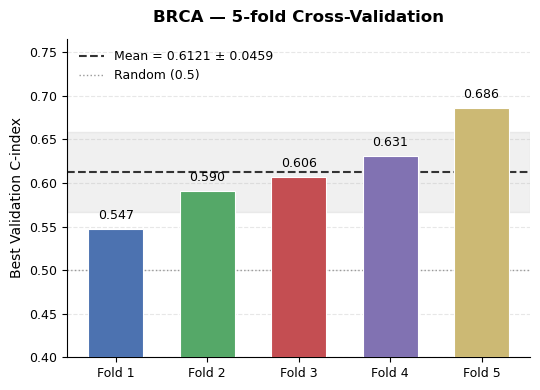


Mean best val C-index: 0.6121 ± 0.0459

Fold 1 training curves (output/survival_cv/BRCA/fold1/losses.png):


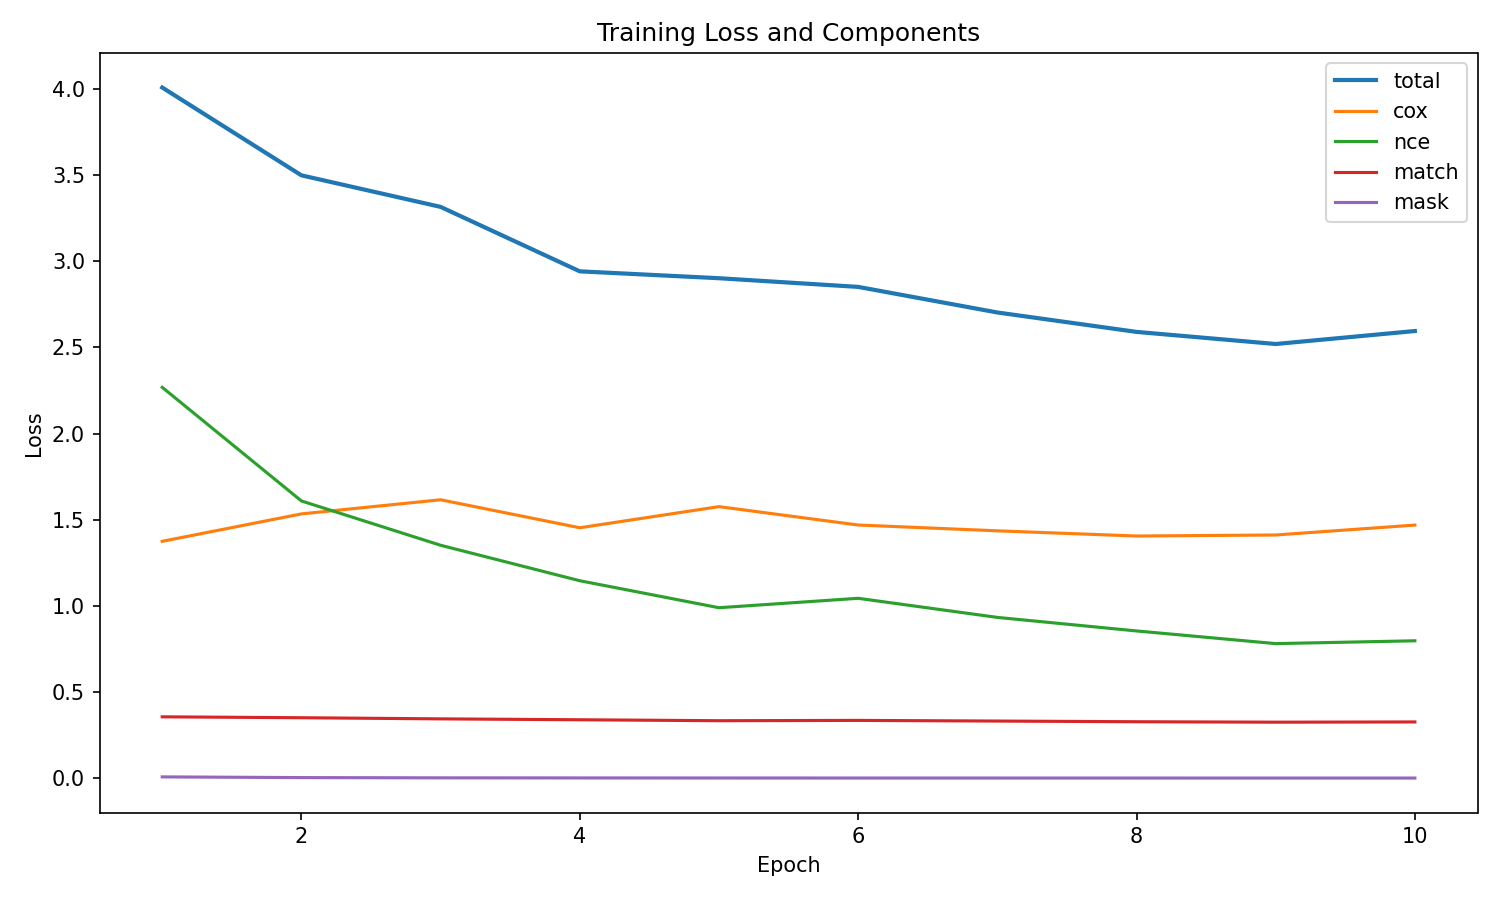

In [ ]:
from IPython.display import Image, display
import matplotlib.ticker as mticker

surv_dir = DESCENT_ROOT / "output" / "survival_cv" / CANCER
summary_path = surv_dir / "cv_summary.json"

if not summary_path.exists():
    print(f"Summary not found: {summary_path} — run Step 4 first.")
else:
    with open(summary_path) as f:
        summary = json.load(f)

    folds = summary["folds"]
    mean_ci = summary["mean_best_val_c_index"]
    std_ci  = summary["std_best_val_c_index"]
    fold_nums = [int(m["fold"]) for m in folds]
    cis = [m["best_val_c_index"] for m in folds]

    # --- Publication-quality C-index bar chart ---
    fig, ax = plt.subplots(figsize=(5.5, 4))

    palette = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']
    bars = ax.bar([f"Fold {f}" for f in fold_nums], cis,
                  color=palette, edgecolor='white', linewidth=0.8, width=0.6, zorder=3)

    ax.axhline(mean_ci, ls='--', lw=1.5, c='#333333', zorder=2,
               label=f'Mean = {mean_ci:.4f} ± {std_ci:.4f}')
    ax.axhspan(mean_ci - std_ci, mean_ci + std_ci,
               color='#333333', alpha=0.07, zorder=1)
    ax.axhline(0.5, ls=':', lw=1, c='#999999', zorder=2, label='Random (0.5)')

    for bar, v in zip(bars, cis):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.008,
                f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='medium')

    ax.set_ylabel('Best Validation C-index', fontsize=10)
    ax.set_title(f'{CANCER} — 5-fold Cross-Validation', fontsize=12, fontweight='bold', pad=12)
    ax.set_ylim(0.4, max(cis) + 0.08)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.05))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, fontsize=9, loc='upper left')
    ax.tick_params(axis='both', labelsize=9)
    ax.grid(axis='y', alpha=0.3, ls='--', zorder=0)

    plt.tight_layout()
    plt.show()

    print(f"\nMean best val C-index: {mean_ci:.4f} ± {std_ci:.4f}")

    # --- Training curves (pre-generated by the survival script) ---
    losses_png = surv_dir / "fold1" / "losses.png"
    if losses_png.exists():
        print(f"\nFold 1 training curves ({losses_png.relative_to(DESCENT_ROOT)}):")
        display(Image(filename=str(losses_png)))
    else:
        print(f"\nlosses.png not found at {losses_png}")

## Summary

| Step | Script | Output |
|------|--------|--------|
| 1. ReDeconv | `scgep_generation/pipeline_scripts/run_redeconv_full.py` | `output/redeconv_fraction/{CANCER}/` |
| 2. scDiffusion Training | `scgep_generation/pipeline_scripts/run_scdiffusion_training.py` | `output/scdiffusion_models/{CANCER}/` |
| 3. Condgen | `scgep_generation/generate_bulk_from_diffusion.py` | `output/scgep_condgen/{CANCER}/redeconv/` |
| 4. Survival CV | `survival_prediction/scrna_bulk_sc_survival_cv.py` | `output/survival_cv/{CANCER}/cv_summary.json` |

DEG lists are assumed pre-computed. To generate per-fold DEGs, run `./scripts/run_deg_all_cancers.sh {CANCER}` before this notebook.

### Shell script equivalents

```bash
# ReDeconv + scDiffusion training + Condgen
./scripts/run_part1_deg_redeconv_condgen.sh BRCA

# Force retraining before condgen
SCDIFFUSION_TRAIN_MODE=force ./scripts/run_part1_deg_redeconv_condgen.sh BRCA

# Survival CV
./scripts/run_part2_survival.sh BRCA

# Full pipeline
./scripts/run_full_pipeline_test.sh BRCA
```